In [3]:


!pip install tensorflow
!pip install tensorflow_datasets

In [4]:
import tensorflow as tf
import tensorflow_datasets as tfds
# import seaborn as sns
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.image as mpimg
# import itertools

print(tf.__version__)

2.19.0


In [5]:
cifar10 = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [6]:
# Shuffle the training data first
indices = tf.random.shuffle(tf.range(len(x_train)))
x_train_shuffled = tf.gather(x_train, indices)
y_train_shuffled = tf.gather(y_train, indices)

val_split = 0.2
num_train = int(len(x_train_shuffled) * (1 - val_split))
x_train_final = x_train_shuffled[:num_train]
y_train_final = y_train_shuffled[:num_train]
x_val = x_train_shuffled[num_train:]
y_val = y_train_shuffled[num_train:]

print(f"Training set size: {len(x_train_final)}")
print(f"Validation set size: {len(x_val)}")
print(f"Test set size: {len(x_test)}")

Training set size: 40000
Validation set size: 10000
Test set size: 10000


In [7]:
dataset, info = tfds.load("cifar10", as_supervised=True, with_info=True)
dataset_size = info.splits["train"].num_examples
class_names = info.features["label"].names
n_classes = info.features["label"].num_classes # 5

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.6IADQS_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.6IADQS_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


In [8]:
sample_images = (x_train[:4].astype('float32')) / 255.0  # Normalize to 0-1
# Resize to 299x299 for Xception
images_resized = tf.image.resize(sample_images, (299, 299))

In [ ]:
inputs = tf.keras.applications.xception.preprocess_input(images_resized)

In [10]:
data_augmentation = tf.keras.Sequential([
tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
tf.keras.layers.RandomRotation(factor=0.05, seed=42),
tf.keras.layers.RandomContrast(factor=0.2, seed=42),
tf.keras.layers.RandomZoom(0.1, seed=42),
tf.keras.layers.RandomTranslation(0.1, 0.1, seed=42)
])


In [11]:
batch_size = 32
preprocess = tf.keras.Sequential([
tf.keras.layers.Resizing(height=299, width=299, crop_to_aspect_ratio=True),
tf.keras.layers.Lambda(tf.keras.applications.xception.preprocess_input)
])

train_set = tf.data.Dataset.from_tensor_slices((x_train_final, y_train_final)).map(lambda X, y: (preprocess(data_augmentation(X, training=True)), y)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
valid_set = tf.data.Dataset.from_tensor_slices((x_val, y_val)).map(lambda X, y: (preprocess(X), y)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_set = tf.data.Dataset.from_tensor_slices((x_test, y_test)).map(lambda X, y: (preprocess(X), y)).batch(batch_size)

In [ ]:
base_model = tf.keras.applications.xception.Xception(weights="imagenet", include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
avg = tf.keras.layers.Dense(256, activation="relu")(avg)
avg = tf.keras.layers.Dropout(0.4)(avg)
output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
Model = tf.keras.Model(inputs=base_model.input, outputs=output)
for layer in base_model.layers:
    layer.trainable = False

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
print(len(base_model.layers))

132


In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3, momentum=0.9)
Model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
history = Model.fit(train_set, validation_data=valid_set, epochs=5)
Model.save('warmup_weights.keras')

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 505s 374ms/step - accuracy: 0.5558 - loss: 1.3097 - val_accuracy: 0.8140 - val_loss: 0.6394
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 453s 362ms/step - accuracy: 0.6625 - loss: 0.9760 - val_accuracy: 0.8341 - val_loss: 0.5267
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 455s 364ms/step - accuracy: 0.6889 - loss: 0.8974 - val_accuracy: 0.8446 - val_loss: 0.4861
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 457s 366ms/step - accuracy: 0.7016 - loss: 0.8560 - val_accuracy: 0.8517 - val_loss: 0.4567
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 457s 365ms/step - accuracy: 0.7131 - loss: 0.8267 - val_accuracy: 0.8569 - val_loss: 0.4370


In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0005,
    patience=5,
    restore_best_weights=True  # reverts to the best checkpoint
)
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=2000,
    decay_rate=0.95
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)
Model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
history = Model.fit(train_set, validation_data=valid_set, epochs=30, callbacks = [early_stop])

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 649s 498ms/step - accuracy: 0.8057 - loss: 0.5776 - val_accuracy: 0.9071 - val_loss: 0.2695
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 601s 481ms/step - accuracy: 0.8795 - loss: 0.3514 - val_accuracy: 0.9192 - val_loss: 0.2382
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 607s 485ms/step - accuracy: 0.9120 - loss: 0.2608 - val_accuracy: 0.9236 - val_loss: 0.2309
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 610s 488ms/step - accuracy: 0.9320 - loss: 0.2025 - val_accuracy: 0.9307 - val_loss: 0.2073
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 608s 486ms/step - accuracy: 0.9467 - loss: 0.1568 - val_accuracy: 0.9305 - val_loss: 0.2309
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 609s 487ms/step - accuracy: 0.9574 - loss: 0.1247 - val_accuracy: 0.9397 - val_loss: 0.2097
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 622s 498ms/step - accuracy: 0.9641 - loss: 0.1038 - val_accuracy: 0.9390 - val_loss: 0.2111
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 638s 510ms/step - ac

In [ ]:
tf.keras.models.save_model(Model, 'my_model.keras')
print("Model saved to my_model.keras")

Model saved to my_model.keras


In [ ]:
test_loss, test_acc = Model.evaluate(test_set)

313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 284ms/step - accuracy: 0.9288 - loss: 0.2218


In [ ]:
base_model.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, None,      │        864 │ input_layer_2[0]… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, None,      │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, None,      │          0 │ block1_conv1_bn[… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, None,      │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, None,      │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, None,      │          0 │ block1_conv2_bn[… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, None,      │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, None,      │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, None,      │          0 │ block2_sepconv1_… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, None,      │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, None,      │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │      8,192 │ block1_conv2_act… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, None,      │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None,      │          0 │ block2_pool[0][0… │
│                     │ None, 128)        │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, None,      │          0 │ add[0][0]       

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 8,940,352 (34.10 MB)

 Non-trainable params: 11,921,128 (45.48 MB)

In [ ]:


Model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0005,
    patience=5,
    restore_best_weights=True
)
history_resume = Model.fit(
    train_set,
    validation_data=valid_set,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 684s 506ms/step - accuracy: 0.9333 - loss: 0.2046 - val_accuracy: 0.9627 - val_loss: 0.1106
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 677s 542ms/step - accuracy: 0.9370 - loss: 0.1940 - val_accuracy: 0.9636 - val_loss: 0.1062
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 677s 542ms/step - accuracy: 0.9379 - loss: 0.1879 - val_accuracy: 0.9644 - val_loss: 0.1031
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 676s 541ms/step - accuracy: 0.9410 - loss: 0.1799 - val_accuracy: 0.9655 - val_loss: 0.1016
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 673s 539ms/step - accuracy: 0.9424 - loss: 0.1758 - val_accuracy: 0.9655 - val_loss: 0.1001


In [ ]:
tf.keras.models.save_model(Model, 'good_model.keras')
print("Model saved to my_model.keras")

Model saved to my_model.keras


In [ ]:
test_loss, test_acc = Model.evaluate(test_set)

313/313 ━━━━━━━━━━━━━━━━━━━━ 95s 305ms/step - accuracy: 0.9460 - loss: 0.1683


In [ ]:
import tensorflow as tf

Model.trainable = True

fine_tune_at = "block13_sepconv1"

trainable = False
for layer in Model.layers:
    if layer.name == fine_tune_at:
        trainable = True
    layer.trainable = trainable

optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4)

Model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

trainable_count = sum([1 for l in Model.layers if l.trainable])
print(f"Compilation complete! {trainable_count} layers are now trainable.")

history_phase2 = Model.fit(
    train_set,
    validation_data=valid_set,
    epochs=10,
    callbacks=[early_stop]
)

Compilation complete! 19 layers are now trainable.
Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 644s 499ms/step - accuracy: 0.9437 - loss: 0.1712 - val_accuracy: 0.9668 - val_loss: 0.0974
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 604s 483ms/step - accuracy: 0.9479 - loss: 0.1566 - val_accuracy: 0.9671 - val_loss: 0.0981
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 600s 480ms/step - accuracy: 0.9520 - loss: 0.1460 - val_accuracy: 0.9667 - val_loss: 0.0990
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 601s 480ms/step - accuracy: 0.9548 - loss: 0.1370 - val_accuracy: 0.9663 - val_loss: 0.0999
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 601s 481ms/step - accuracy: 0.9574 - loss: 0.1319 - val_accuracy: 0.9664 - val_loss: 0.0999
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 600s 480ms/step - accuracy: 0.9588 - loss: 0.1232 - val_accuracy: 0.9667 - val_loss: 0.1014


In [ ]:
test_loss, test_acc = Model.evaluate(test_set)

313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 305ms/step - accuracy: 0.9484 - loss: 0.1651


In [ ]:
tf.keras.models.save_model(Model, 'final_good_model.keras')
print("Model saved to my_model.keras")

Model saved to my_model.keras


In [2]:
from tensorflow.keras.models import load_model

model = load_model('final_good_model.keras')

In [12]:
test_loss, test_acc = model.evaluate(test_set)

313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step - accuracy: 0.9486 - loss: 0.1650


313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step

--- Classification Report ---
              precision    recall  f1-score   support

    airplane       0.98      0.97      0.97      1000
  automobile       0.97      0.99      0.98      1000
        bird       0.96      0.93      0.94      1000
         cat       0.89      0.88      0.88      1000
        deer       0.94      0.95      0.94      1000
         dog       0.93      0.90      0.91      1000
        frog       0.93      0.98      0.95      1000
       horse       0.97      0.95      0.96      1000
        ship       0.97      0.97      0.97      1000
       truck       0.97      0.96      0.97      1000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



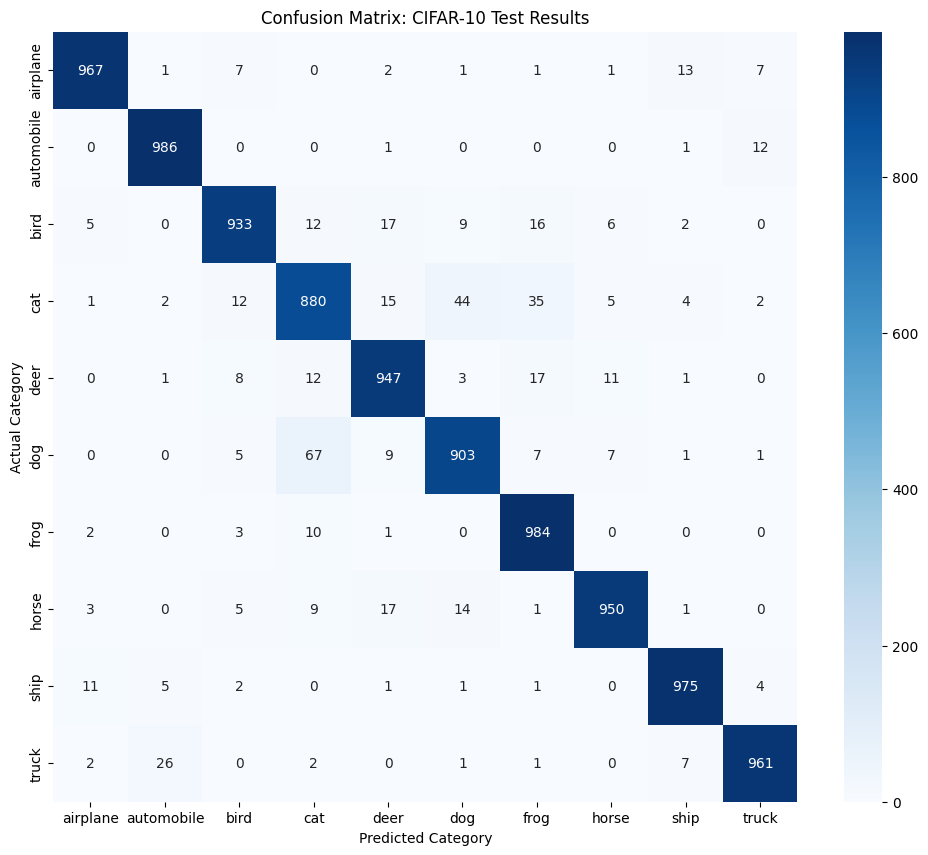

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_true = np.concatenate([y for x, y in test_set], axis=0)

y_pred_probs = model.predict(test_set)
y_pred = np.argmax(y_pred_probs, axis=1)

target_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("\n--- Classification Report ---")
report = classification_report(y_true, y_pred, target_names=target_names)
print(report)

plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix: CIFAR-10 Test Results')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()